In [78]:
import pandas as pd 
import seaborn as sns

In [2]:
mimic_path = 'data/mimic-iv-clinical-database-demo-2.2'

patients_df = pd.read_csv(f'{mimic_path}/hosp/patients.csv')
patients_df

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09
...,...,...,...,...,...,...
95,10004733,M,51,2174,2014 - 2016,NaN
96,10021118,M,62,2161,2014 - 2016,NaN
97,10018501,M,83,2141,2014 - 2016,NaN
98,10007058,M,48,2167,2014 - 2016,NaN


In [3]:
caregiver_df = pd.read_csv(f'{mimic_path}/icu/caregiver.csv')
caregiver_df

,caregiver_id
0,444
1,1016
2,1135
3,1172
4,1353
...,...
15463,98368
15464,99539
15465,99577
15466,99807


In [4]:
icu_df = pd.read_csv(f'{mimic_path}/icu/icustays.csv')
icu_df

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106
...,...,...,...,...,...,...,...,...
135,10020786,23488445,33683112,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2189-06-09 12:46:30,2189-06-10 22:58:09,1.424757
136,10020740,23831430,35026312,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2150-03-11 15:34:56,2150-03-19 02:17:47,7.446424
137,10032725,20611640,30101877,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2143-03-22 06:42:00,2143-03-25 15:05:33,3.349687
138,10037928,24656677,39804682,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2178-12-21 06:05:18,2178-12-22 02:16:08,0.840856


In [5]:
chart_df = pd.read_csv(f'{mimic_path}/icu/chartevents.csv')
chart_df

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
668857,10019003,29279905,34107647,60023.0,2153-03-28 10:49:28,NaN,220001,.Care Plan - Infection,NaN,NaN,NaN
668858,10019003,29279905,34107647,60023.0,2153-03-28 10:49:28,NaN,220001,"Diabetes Mellitus (DM), Type II",NaN,NaN,NaN
668859,10019003,29279905,34107647,60023.0,2153-03-28 10:49:28,NaN,220001,.Care Plan - Coping,NaN,NaN,NaN
668860,10019003,29279905,34107647,60023.0,2153-03-28 10:49:28,NaN,220001,"Chronic obstructive pulmonary disease (COPD, B...",NaN,NaN,NaN


In [6]:
chart_df['itemid'].nunique()

1318

In [7]:
chart_df['subject_id'].nunique()

# groupby subject id and count itemid or something

100

In [8]:
output_df = pd.read_csv(f'{mimic_path}/icu/outputevents.csv')
output_df

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valueuom
0,10002428,23473524,35479615,29441,2156-05-15 18:00:00,2156-05-15 17:42:00,226583,600,ml
1,10002428,23473524,35479615,29441,2156-05-15 12:00:00,2156-05-15 12:08:00,226559,60,ml
2,10002428,23473524,35479615,29441,2156-05-15 13:00:00,2156-05-15 13:00:00,226559,45,ml
3,10002428,23473524,35479615,29441,2156-05-15 08:00:00,2156-05-15 08:39:00,226559,125,ml
4,10002428,23473524,35479615,29441,2156-05-15 14:00:00,2156-05-15 13:56:00,226559,60,ml
...,...,...,...,...,...,...,...,...,...
9357,10016742,29281842,37057036,82943,2178-07-07 11:00:00,2178-07-07 13:25:00,226559,230,ml
9358,10016742,29281842,37057036,82943,2178-07-07 15:00:00,2178-07-07 17:40:00,226559,120,ml
9359,10016742,29281842,37057036,82943,2178-07-07 09:00:00,2178-07-07 09:25:00,226559,250,ml
9360,10016742,29281842,37057036,82943,2178-07-07 18:00:00,2178-07-07 18:18:00,226559,80,ml


### chart_df exploration

In [9]:
# Obtain row with the targetted itemid
map_df = chart_df[chart_df['itemid'].isin([220181, 220052, 225312])]
map_df

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
65,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220052,58,58.0,mmHg,0.0
107,10005817,20626031,32604416,6770.0,2132-12-16 01:00:00,2132-12-16 01:04:00,220052,63,63.0,mmHg,0.0
123,10005817,20626031,32604416,6770.0,2132-12-16 02:00:00,2132-12-16 02:11:00,220052,58,58.0,mmHg,0.0
139,10005817,20626031,32604416,6770.0,2132-12-16 03:00:00,2132-12-16 03:00:00,220052,59,59.0,mmHg,0.0
170,10005817,20626031,32604416,6770.0,2132-12-16 04:00:00,2132-12-16 04:21:00,220052,66,66.0,mmHg,0.0
...,...,...,...,...,...,...,...,...,...,...,...
667790,10019003,29279905,34107647,60023.0,2153-03-28 11:19:00,2153-03-28 11:20:00,220181,65,65.0,mmHg,0.0
668042,10019003,29279905,34107647,60023.0,2153-03-28 18:27:00,2153-03-28 18:29:00,220181,72,72.0,mmHg,0.0
668304,10019003,29279905,34107647,60023.0,2153-03-28 08:35:00,2153-03-28 09:10:00,220181,68,68.0,mmHg,0.0
668459,10019003,29279905,34107647,47425.0,2153-03-31 10:43:00,2153-03-31 10:44:00,220181,57,57.0,mmHg,0.0


In [10]:
map_df['charttime'].nunique()

13996

In [11]:
# 1. Convert charttime to proper datetime objects
map_df['charttime'] = pd.to_datetime(map_df['charttime'])

# 2. Pivot the table
df_pivoted = pd.pivot_table(
    map_df,
    index=['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime'],
    columns='itemid',
    values='valuenum',  # <-- REMOVED the square brackets here
    aggfunc='first' 
)

# 3. Clean up the axis name (optional, but removes the floating 'itemid' label over the index)
df_pivoted.columns.name = None

# 4. Flatten the index
df_pivoted.reset_index(inplace=True)

# Now your columns will just be: subject_id, hadm_id, stay_id, caregiver_id, charttime, 220052, 220181, 225312

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/3608285404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  map_df['charttime'] = pd.to_datetime(map_df['charttime'])


In [12]:
df_pivoted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,220052,220181,225312
0,10000032,29079034,39553978,47007.0,2180-07-23 21:01:00,NaN,63.0,NaN
1,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,NaN,62.0,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,NaN,56.0,NaN
3,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,NaN,64.0,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,NaN,56.0,NaN
...,...,...,...,...,...,...,...,...
14006,10040025,27996267,36107367,84976.0,2148-01-29 15:03:00,NaN,65.0,NaN
14007,10040025,27996267,36107367,84976.0,2148-01-29 16:04:00,NaN,76.0,NaN
14008,10040025,27996267,36107367,84976.0,2148-01-29 17:02:00,NaN,73.0,NaN
14009,10040025,27996267,36107367,84976.0,2148-01-29 18:02:00,NaN,62.0,NaN


In [13]:
df_item_converted = pd.read_csv(f'{mimic_path}/icu/d_items.csv')
df_item_converted = df_item_converted[['itemid','label','abbreviation']]
df_item_converted[df_item_converted['itemid'].isin([220181, 220052, 225312])]

,itemid,label,abbreviation
2566,220052,Arterial Blood Pressure mean,ABPm
2575,220181,Non Invasive Blood Pressure mean,NBPm
2588,225312,ART BP Mean,ART BP Mean


In [14]:
df_item_converted.to_csv('d_items_label.csv', index=False)

In [15]:
# 1. Create a dictionary mapping the itemid to the full 'label'
id_to_label = dict(zip(df_item_converted['itemid'], df_item_converted['label']))

# Add string versions just in case the pivot table made the column names strings
id_to_label.update(dict(zip(df_item_converted['itemid'].astype(str), df_item_converted['label'])))

# 2. Rename the columns
df_pivoted.rename(columns=id_to_label, inplace=True)
df_pivoted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,Arterial Blood Pressure mean,Non Invasive Blood Pressure mean,ART BP Mean
0,10000032,29079034,39553978,47007.0,2180-07-23 21:01:00,NaN,63.0,NaN
1,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,NaN,62.0,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,NaN,56.0,NaN
3,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,NaN,64.0,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,NaN,56.0,NaN
...,...,...,...,...,...,...,...,...
14006,10040025,27996267,36107367,84976.0,2148-01-29 15:03:00,NaN,65.0,NaN
14007,10040025,27996267,36107367,84976.0,2148-01-29 16:04:00,NaN,76.0,NaN
14008,10040025,27996267,36107367,84976.0,2148-01-29 17:02:00,NaN,73.0,NaN
14009,10040025,27996267,36107367,84976.0,2148-01-29 18:02:00,NaN,62.0,NaN


In [16]:
df_pivoted.isna().sum()

subject_id                              0
hadm_id                                 0
stay_id                                 0
caregiver_id                            0
charttime                               0
Arterial Blood Pressure mean         8451
Non Invasive Blood Pressure mean     5669
ART BP Mean                         13523
dtype: int64

In [17]:
# 1. Combine the two invasive measurements. 
# It checks the first arterial code, and if missing, checks the second arterial code.
invasive_map = df_pivoted['Arterial Blood Pressure mean'].combine_first(df_pivoted['ART BP Mean'])

# 2. Create the final standardized 'MAP' column.
# It takes the invasive_map we just made, and if it's STILL missing, 
# it falls back to the non-invasive cuff measurement.
df_pivoted['MAP'] = invasive_map.combine_first(df_pivoted['Non Invasive Blood Pressure mean'])

# 3. Clean up by dropping the old individual columns so your dataframe stays neat
df_pivoted = df_pivoted.drop(columns=[
    'Arterial Blood Pressure mean', 
    'ART BP Mean', 
    'Non Invasive Blood Pressure mean'
])


In [18]:
df_pivoted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP
0,10000032,29079034,39553978,47007.0,2180-07-23 21:01:00,63.0
1,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,62.0
2,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,56.0
3,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,64.0
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0
...,...,...,...,...,...,...
14006,10040025,27996267,36107367,84976.0,2148-01-29 15:03:00,65.0
14007,10040025,27996267,36107367,84976.0,2148-01-29 16:04:00,76.0
14008,10040025,27996267,36107367,84976.0,2148-01-29 17:02:00,73.0
14009,10040025,27996267,36107367,84976.0,2148-01-29 18:02:00,62.0


In [19]:
df_pivoted_sorted = df_pivoted.sort_values(by=['subject_id','charttime'], ascending=[True, True])
df_pivoted_sorted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0
5,10000032,29079034,39553978,88981.0,2180-07-23 14:30:00,67.0
6,10000032,29079034,39553978,88981.0,2180-07-23 15:00:00,64.0
7,10000032,29079034,39553978,88981.0,2180-07-23 16:01:00,64.0
8,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,67.0
...,...,...,...,...,...,...
13832,10040025,27996267,36107367,27035.0,2148-01-30 12:03:00,86.0
13833,10040025,27996267,36107367,27035.0,2148-01-30 13:02:00,85.0
13834,10040025,27996267,36107367,27035.0,2148-01-30 14:02:00,96.0
13835,10040025,27996267,36107367,27035.0,2148-01-30 15:02:00,80.0


In [20]:
df_pivoted_sorted['charttime'] = pd.to_datetime(df_pivoted_sorted['charttime'])
df_pivoted_sorted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0
5,10000032,29079034,39553978,88981.0,2180-07-23 14:30:00,67.0
6,10000032,29079034,39553978,88981.0,2180-07-23 15:00:00,64.0
7,10000032,29079034,39553978,88981.0,2180-07-23 16:01:00,64.0
8,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,67.0
...,...,...,...,...,...,...
13832,10040025,27996267,36107367,27035.0,2148-01-30 12:03:00,86.0
13833,10040025,27996267,36107367,27035.0,2148-01-30 13:02:00,85.0
13834,10040025,27996267,36107367,27035.0,2148-01-30 14:02:00,96.0
13835,10040025,27996267,36107367,27035.0,2148-01-30 15:02:00,80.0


In [21]:
df_map_pivoted = df_pivoted_sorted.copy()
df_map_pivoted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP
4,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0
5,10000032,29079034,39553978,88981.0,2180-07-23 14:30:00,67.0
6,10000032,29079034,39553978,88981.0,2180-07-23 15:00:00,64.0
7,10000032,29079034,39553978,88981.0,2180-07-23 16:01:00,64.0
8,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,67.0
...,...,...,...,...,...,...
13832,10040025,27996267,36107367,27035.0,2148-01-30 12:03:00,86.0
13833,10040025,27996267,36107367,27035.0,2148-01-30 13:02:00,85.0
13834,10040025,27996267,36107367,27035.0,2148-01-30 14:02:00,96.0
13835,10040025,27996267,36107367,27035.0,2148-01-30 15:02:00,80.0


In [22]:
# This result basically presents that I have to do hourly prediction as number is quite close to 60 minutes
def get_average_sampling_interval(df, itemid_col='itemid', time_col='charttime'):
    """
    Calculates the average time (in minutes) between successive measurements
    per patient (stay_id).
    """
    # Ensure time is datetime
    df[time_col] = pd.to_datetime(df[time_col])
    
    # Sort to ensure chronological order
    df = df.sort_values(['stay_id', time_col])
    
    # Calculate difference between rows within each stay_id
    df['time_diff'] = df.groupby('stay_id')[time_col].diff().dt.total_seconds() / 60
    
    # Return average (ignoring NaNs from the first row of each group)
    avg_diff = df['time_diff'].mean()
    
    return avg_diff


avg_map_interval = get_average_sampling_interval(df_map_pivoted)
avg_map_interval

np.float64(51.971309111880046)

In [23]:
df_map_pivoted.dtypes

subject_id               int64
hadm_id                  int64
stay_id                  int64
caregiver_id           float64
charttime       datetime64[ns]
MAP                    float64
dtype: object

In [ ]:
# Assuming your df is indexed by charttime
# This will calculate the mean for all vitals in the 1-hour window
df_map_hourly = df_map_pivoted.groupby(['subject_id', 'hadm_id', 'stay_id']).resample('1H', on='charttime')['MAP'].mean().reset_index()
df_map_hourly

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/3243042402.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_map_hourly = df_map_pivoted.groupby(['subject_id', 'hadm_id', 'stay_id']).resample('1H', on='charttime')['MAP'].mean().reset_index()


,subject_id,hadm_id,stay_id,charttime,MAP
0,10000032,29079034,39553978,2180-07-23 14:00:00,62.5
1,10000032,29079034,39553978,2180-07-23 15:00:00,56.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,64.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,56.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,67.0
...,...,...,...,...,...
180109,10040025,27996267,36107367,2148-01-30 12:00:00,65.0
180110,10040025,27996267,36107367,2148-01-30 13:00:00,76.0
180111,10040025,27996267,36107367,2148-01-30 14:00:00,73.0
180112,10040025,27996267,36107367,2148-01-30 15:00:00,62.0


In [25]:
reduced_df = chart_df['itemid'].value_counts().head(200).reset_index()
reduced_df = reduced_df.merge(df_item_converted, on='itemid', how='left')
reduced_df

,itemid,count,label,abbreviation
0,227969,19330,Safety Measures,Safety Measures
1,220045,13913,Heart Rate,HR
2,220210,13913,Respiratory Rate,RR
3,220277,13540,O2 saturation pulseoxymetry,SpO2
4,220048,12460,Heart Rhythm,Heart Rhythm
...,...,...,...,...
195,228307,1032,GI #1 Tube Place Check,GI #1 Tube Place Check
196,228306,1028,Assistance Device,Assistance Device
197,224072,1013,Education Learner,Education Learner
198,228393,1007,Bath,Bath


In [26]:
reduced_df.to_csv('top_200_items.csv', index=False)

In [27]:
### Static Exogenous Factors
patients_df = pd.read_csv(f'{mimic_path}/hosp/patients.csv')
patients_df = patients_df[['subject_id', 'gender', 'anchor_age', 'anchor_year']]
patients_df

,subject_id,gender,anchor_age,anchor_year
0,10014729,F,21,2125
1,10003400,F,72,2134
2,10002428,F,80,2155
3,10032725,F,38,2143
4,10027445,F,48,2142
...,...,...,...,...
95,10004733,M,51,2174
96,10021118,M,62,2161
97,10018501,M,83,2141
98,10007058,M,48,2167


In [28]:
patients_df[patients_df['subject_id'] == 10040025]

,subject_id,gender,anchor_age,anchor_year
7,10040025,F,64,2143


In [29]:
### Combined static information
# 1. Merge the static patient data onto your hourly time-series dataframe
df_map_static = df_pivoted_sorted.merge(
    patients_df[['subject_id', 'gender', 'anchor_age', 'anchor_year']], 
    on='subject_id', 
    how='left'
)

# 2. Calculate the true age at the exact time of the ICU stay
# (Charttime Year - Anchor Year) + Anchor Age
df_map_static['age'] = df_map_static['anchor_age'] + (df_map_static['charttime'].dt.year - df_map_static['anchor_year'])

# 3. Clean up the unneeded columns
df_map_static = df_map_static.drop(columns=['anchor_age', 'anchor_year'])

# 4. Convert Gender to a binary feature for the model (e.g., M = 0, F = 1)
df_map_static['gender_female'] = (df_map_static['gender'] == 'F').astype(int)
df_map_static = df_map_static.drop(columns=['gender'])

# Look at your perfect, clinically accurate features!
print(df_map_static[['subject_id', 'stay_id', 'charttime', 'age', 'gender_female']].head())

   subject_id   stay_id           charttime  age  gender_female
0    10000032  39553978 2180-07-23 14:11:00   52              1
1    10000032  39553978 2180-07-23 14:30:00   52              1
2    10000032  39553978 2180-07-23 15:00:00   52              1
3    10000032  39553978 2180-07-23 16:01:00   52              1
4    10000032  39553978 2180-07-23 17:00:00   52              1


In [30]:
df_map_static

,subject_id,hadm_id,stay_id,caregiver_id,charttime,MAP,age,gender_female
0,10000032,29079034,39553978,88981.0,2180-07-23 14:11:00,56.0,52,1
1,10000032,29079034,39553978,88981.0,2180-07-23 14:30:00,67.0,52,1
2,10000032,29079034,39553978,88981.0,2180-07-23 15:00:00,64.0,52,1
3,10000032,29079034,39553978,88981.0,2180-07-23 16:01:00,64.0,52,1
4,10000032,29079034,39553978,88981.0,2180-07-23 17:00:00,67.0,52,1
...,...,...,...,...,...,...,...,...
14006,10040025,27996267,36107367,27035.0,2148-01-30 12:03:00,86.0,69,1
14007,10040025,27996267,36107367,27035.0,2148-01-30 13:02:00,85.0,69,1
14008,10040025,27996267,36107367,27035.0,2148-01-30 14:02:00,96.0,69,1
14009,10040025,27996267,36107367,27035.0,2148-01-30 15:02:00,80.0,69,1


In [31]:
df_map_static.isna().sum()

subject_id       0
hadm_id          0
stay_id          0
caregiver_id     0
charttime        0
MAP              0
age              0
gender_female    0
dtype: int64

In [32]:
agg_rules_map = {
    'MAP': 'mean',
    'age': 'first', 
    'gender_female': 'first'}

df_map_static_hourly = df_map_static.groupby(['subject_id', 'hadm_id', 'stay_id']).resample('1H', on='charttime').agg(agg_rules_map).reset_index()
df_map_static_hourly

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/169143339.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_map_static_hourly = df_map_static.groupby(['subject_id', 'hadm_id', 'stay_id']).resample('1H', on='charttime').agg(agg_rules_map).reset_index()


,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
0,10000032,29079034,39553978,2180-07-23 14:00:00,61.5,52.0,1.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,64.0,52.0,1.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,64.0,52.0,1.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,67.0,52.0,1.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,60.0,52.0,1.0
...,...,...,...,...,...,...,...
12207,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0
12208,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0
12209,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0
12210,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0


In [33]:
df_map_static_hourly[df_map_static_hourly['MAP'].isna()].sort_values(['subject_id', 'charttime']).head(50)

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
28,10001217,24597018,37067082,2157-11-21 14:00:00,NaN,NaN,NaN
54,10001217,27703517,34592300,2157-12-20 09:00:00,NaN,NaN,NaN
628,10002428,28662225,38875437,2156-04-24 06:00:00,NaN,NaN,NaN
117,10002428,20321825,34807493,2156-05-02 00:00:00,NaN,NaN,NaN
249,10002428,23473524,35479615,2156-05-16 06:00:00,NaN,NaN,NaN
714,10002495,24982426,36753294,2141-05-23 21:00:00,NaN,NaN,NaN
715,10002495,24982426,36753294,2141-05-23 22:00:00,NaN,NaN,NaN
834,10002930,25696644,37049133,2196-04-15 12:00:00,NaN,NaN,NaN
1036,10003400,20214994,32128372,2137-03-03 14:00:00,NaN,NaN,NaN
1072,10003400,20214994,32128372,2137-03-05 02:00:00,NaN,NaN,NaN


In [34]:
df_map_static_hourly = df_map_static_hourly.set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime'])

# 2. Perform the fill within each stay_id group
# Since stay_id is in the index, it won't be lost
df_map_static_hourly = df_map_static_hourly.groupby('stay_id').ffill()

# 3. Bring the IDs back as columns
df_map_static_hourly = df_map_static_hourly.reset_index()

In [35]:
df_map_static_hourly.isna().sum()

subject_id       0
hadm_id          0
stay_id          0
charttime        0
MAP              0
age              0
gender_female    0
dtype: int64

<Axes: xlabel='MAP'>

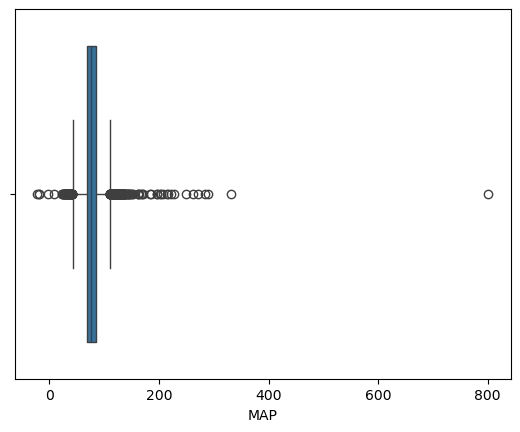

In [79]:
### Deal with outlier values in MAP
sns.boxplot(x=df_map_static_hourly['MAP'])

In [80]:
IQR = df_map_static_hourly['MAP'].quantile(0.75) - df_map_static_hourly['MAP'].quantile(0.25)
upper_outlier_value = df_map_static_hourly['MAP'].quantile(0.75) + 1.5 * IQR
lower_outlier_value = df_map_static_hourly['MAP'].quantile(0.25) - 1.5 * IQR
print(f"Upper Outlier Threshold: {upper_outlier_value}")
print(f"Lower Outlier Threshold: {lower_outlier_value}")

Upper Outlier Threshold: 110.5
Lower Outlier Threshold: 42.5


In [81]:
df_map_static_hourly[df_map_static_hourly['MAP'] > upper_outlier_value]

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
18,10001217,24597018,37067082,2157-11-21 04:00:00,130.0,55.0,1.0
36,10001217,27703517,34592300,2157-12-19 15:00:00,114.0,55.0,1.0
37,10001217,27703517,34592300,2157-12-19 16:00:00,112.0,55.0,1.0
91,10002428,20321825,34807493,2156-04-30 22:00:00,112.0,81.0,1.0
224,10002428,23473524,35479615,2156-05-15 05:00:00,111.0,81.0,1.0
...,...,...,...,...,...,...,...
11622,10039708,28258130,33281088,2140-01-24 14:00:00,186.0,48.0,1.0
11892,10039708,28258130,33281088,2140-02-04 20:00:00,138.0,48.0,1.0
11944,10039708,28258130,33281088,2140-02-07 00:00:00,331.0,48.0,1.0
12030,10039997,24294180,36893762,2134-09-07 21:00:00,111.0,67.0,1.0


### Obtaining Exogenous Factor from chartevents

In [36]:
# Obtain row with the targetted itemid
chart_features = [220045, 220210, 220277, 223761, 220739, 223901, 223900, 220339, 223835]
chart_features_df = chart_df[chart_df['itemid'].isin(chart_features)]
chart_features_df

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
37,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220210,19,19.0,insp/min,0.0
63,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,223901,Obeys Commands,6.0,NaN,0.0
69,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220045,80,80.0,bpm,0.0
75,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,220739,To Speech,3.0,NaN,0.0
84,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:46:00,223900,Oriented,5.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
668710,10019003,29279905,34107647,68979.0,2153-03-28 02:56:00,2153-03-28 02:57:00,220277,95,95.0,%,0.0
668738,10019003,29279905,34107647,68979.0,2153-03-28 02:57:00,2153-03-28 02:57:00,220210,19,19.0,insp/min,0.0
668741,10019003,29279905,34107647,68979.0,2153-03-28 02:57:00,2153-03-28 02:57:00,220045,99,99.0,bpm,0.0
668742,10019003,29279905,34107647,68979.0,2153-03-28 02:57:00,2153-03-28 02:57:00,223761,97.8,97.8,°F,0.0


In [37]:
# 1. Convert charttime to proper datetime objects
chart_features_df['charttime'] = pd.to_datetime(chart_features_df['charttime'])

# 2. Pivot the table
df_chart_features_pivotted = pd.pivot_table(
    chart_features_df,
    index=['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime'],
    columns='itemid',
    values='valuenum',  
    aggfunc='first' 
)

# 3. Clean up the axis name (optional, but removes the floating 'itemid' label over the index)
df_chart_features_pivotted.columns.name = None

# 4. Flatten the index
df_chart_features_pivotted.reset_index(inplace=True)

df_chart_features_pivotted

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/4005379468.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chart_features_df['charttime'] = pd.to_datetime(chart_features_df['charttime'])


,subject_id,hadm_id,stay_id,caregiver_id,charttime,220045,220210,220277,220339,220739,223761,223835,223900,223901
0,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,94.0,20.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN
1,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,97.0,16.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,100.0,19.0,99.0,NaN,4.0,99.5,NaN,5.0,6.0
3,10000032,29079034,39553978,66056.0,2180-07-23 21:00:00,94.0,22.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:00:00,NaN,NaN,NaN,NaN,NaN,98.7,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,10040025,27996267,36107367,84976.0,2148-01-29 15:01:00,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN
18068,10040025,27996267,36107367,84976.0,2148-01-29 16:00:00,84.0,19.0,98.0,NaN,4.0,97.6,NaN,5.0,6.0
18069,10040025,27996267,36107367,84976.0,2148-01-29 17:00:00,82.0,17.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN
18070,10040025,27996267,36107367,84976.0,2148-01-29 18:00:00,93.0,13.0,99.0,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df_item_converted = pd.read_csv(f'{mimic_path}/icu/d_items.csv')
df_item_converted = df_item_converted[['itemid','label','abbreviation']]
df_item_converted[df_item_converted['itemid'].isin(chart_features)]

,itemid,label,abbreviation
621,223901,GCS - Motor Response,Motor Response
627,223900,GCS - Verbal Response,Verbal Response
639,220739,GCS - Eye Opening,Eye Opening
2327,220277,O2 saturation pulseoxymetry,SpO2
2329,220210,Respiratory Rate,RR
2338,223835,Inspired O2 Fraction,FiO2
2350,220339,PEEP set,PEEP set
2570,223761,Temperature Fahrenheit,Temperature F
2577,220045,Heart Rate,HR


In [39]:
# 1. Create a dictionary mapping the itemid to the full 'label'
id_to_label = dict(zip(df_item_converted['itemid'], df_item_converted['label']))

# Add string versions just in case the pivot table made the column names strings
id_to_label.update(dict(zip(df_item_converted['itemid'].astype(str), df_item_converted['label'])))

# 2. Rename the columns
df_chart_features_pivotted.rename(columns=id_to_label, inplace=True)
df_chart_features_pivotted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,PEEP set,GCS - Eye Opening,Temperature Fahrenheit,Inspired O2 Fraction,GCS - Verbal Response,GCS - Motor Response
0,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,94.0,20.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN
1,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,97.0,16.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,100.0,19.0,99.0,NaN,4.0,99.5,NaN,5.0,6.0
3,10000032,29079034,39553978,66056.0,2180-07-23 21:00:00,94.0,22.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:00:00,NaN,NaN,NaN,NaN,NaN,98.7,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,10040025,27996267,36107367,84976.0,2148-01-29 15:01:00,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN
18068,10040025,27996267,36107367,84976.0,2148-01-29 16:00:00,84.0,19.0,98.0,NaN,4.0,97.6,NaN,5.0,6.0
18069,10040025,27996267,36107367,84976.0,2148-01-29 17:00:00,82.0,17.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN
18070,10040025,27996267,36107367,84976.0,2148-01-29 18:00:00,93.0,13.0,99.0,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
df_chart_features_pivotted.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime',
       'Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry',
       'PEEP set', 'GCS - Eye Opening', 'Temperature Fahrenheit',
       'Inspired O2 Fraction', 'GCS - Verbal Response',
       'GCS - Motor Response'],
      dtype='object')

In [41]:
df_chart_features_pivotted['GCS'] = df_chart_features_pivotted['GCS - Eye Opening'] + df_chart_features_pivotted['GCS - Motor Response'] + df_chart_features_pivotted['GCS - Verbal Response']
df_chart_features_pivotted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,PEEP set,GCS - Eye Opening,Temperature Fahrenheit,Inspired O2 Fraction,GCS - Verbal Response,GCS - Motor Response,GCS
0,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,94.0,20.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,97.0,16.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,100.0,19.0,99.0,NaN,4.0,99.5,NaN,5.0,6.0,15.0
3,10000032,29079034,39553978,66056.0,2180-07-23 21:00:00,94.0,22.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:00:00,NaN,NaN,NaN,NaN,NaN,98.7,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,10040025,27996267,36107367,84976.0,2148-01-29 15:01:00,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18068,10040025,27996267,36107367,84976.0,2148-01-29 16:00:00,84.0,19.0,98.0,NaN,4.0,97.6,NaN,5.0,6.0,15.0
18069,10040025,27996267,36107367,84976.0,2148-01-29 17:00:00,82.0,17.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18070,10040025,27996267,36107367,84976.0,2148-01-29 18:00:00,93.0,13.0,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_chart_features_pivotted.drop(columns=['GCS - Eye Opening', 'GCS - Verbal Response'], inplace=True)
df_chart_features_pivotted

,subject_id,hadm_id,stay_id,caregiver_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,PEEP set,Temperature Fahrenheit,Inspired O2 Fraction,GCS - Motor Response,GCS
0,10000032,29079034,39553978,47007.0,2180-07-23 22:00:00,94.0,20.0,95.0,NaN,NaN,NaN,NaN,NaN
1,10000032,29079034,39553978,66056.0,2180-07-23 19:00:00,97.0,16.0,98.0,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,39553978,66056.0,2180-07-23 20:00:00,100.0,19.0,99.0,NaN,99.5,NaN,6.0,15.0
3,10000032,29079034,39553978,66056.0,2180-07-23 21:00:00,94.0,22.0,95.0,NaN,NaN,NaN,NaN,NaN
4,10000032,29079034,39553978,88981.0,2180-07-23 14:00:00,NaN,NaN,NaN,NaN,98.7,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18067,10040025,27996267,36107367,84976.0,2148-01-29 15:01:00,NaN,NaN,100.0,NaN,NaN,NaN,NaN,NaN
18068,10040025,27996267,36107367,84976.0,2148-01-29 16:00:00,84.0,19.0,98.0,NaN,97.6,NaN,6.0,15.0
18069,10040025,27996267,36107367,84976.0,2148-01-29 17:00:00,82.0,17.0,98.0,NaN,NaN,NaN,NaN,NaN
18070,10040025,27996267,36107367,84976.0,2148-01-29 18:00:00,93.0,13.0,99.0,NaN,NaN,NaN,NaN,NaN


In [43]:
df_chart_features_pivotted.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime',
       'Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry',
       'PEEP set', 'Temperature Fahrenheit', 'Inspired O2 Fraction',
       'GCS - Motor Response', 'GCS'],
      dtype='object')

In [44]:
# Performing Aggregation to hourly level
agg_rules = {
    'Heart Rate': 'mean',
    'Respiratory Rate': 'mean',
    'O2 saturation pulseoxymetry': 'mean',
    'Temperature Fahrenheit': 'mean',
    'PEEP set': 'mean',
    'Inspired O2 Fraction': 'mean',
    'GCS': 'max',
    'GCS - Motor Response': 'max' 
}

df_chart_features_hourly = df_chart_features_pivotted.groupby(['subject_id', 'hadm_id','stay_id']).resample('1H', on='charttime').agg(agg_rules).reset_index()
df_chart_features_hourly

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/1547320356.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_chart_features_hourly = df_chart_features_pivotted.groupby(['subject_id', 'hadm_id','stay_id']).resample('1H', on='charttime').agg(agg_rules).reset_index()


,subject_id,hadm_id,stay_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
0,10000032,29079034,39553978,2180-07-23 14:00:00,92.0,22.5,97.5,98.7,NaN,NaN,14.0,6.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,94.0,23.0,97.0,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,39553978,2180-07-23 16:00:00,105.0,21.0,94.0,NaN,NaN,NaN,NaN,NaN
3,10000032,29079034,39553978,2180-07-23 17:00:00,97.0,20.0,95.0,98.7,NaN,NaN,NaN,NaN
4,10000032,29079034,39553978,2180-07-23 18:00:00,100.0,21.0,95.0,NaN,NaN,NaN,15.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12340,10040025,27996267,36107367,2148-01-30 12:00:00,85.0,23.0,93.0,97.5,NaN,NaN,NaN,NaN
12341,10040025,27996267,36107367,2148-01-30 13:00:00,81.0,15.0,94.0,NaN,NaN,NaN,NaN,NaN
12342,10040025,27996267,36107367,2148-01-30 14:00:00,71.0,15.0,95.0,NaN,NaN,NaN,NaN,NaN
12343,10040025,27996267,36107367,2148-01-30 15:00:00,83.0,14.0,96.0,97.4,NaN,NaN,13.0,6.0


In [45]:
12345 - df_chart_features_hourly.isna().sum()

subject_id                     12345
hadm_id                        12345
stay_id                        12345
charttime                      12345
Heart Rate                     12033
Respiratory Rate               12027
O2 saturation pulseoxymetry    11838
Temperature Fahrenheit          3293
PEEP set                        1401
Inspired O2 Fraction            1693
GCS                             3232
GCS - Motor Response            3239
dtype: int64

In [82]:
# 1. Define your feature groups and their respective 'stale' limits

ffill_limits = {
    'normal': {
        'cols': ['Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry'],
        'limit': 2 # Standard 2-hour window for high-frequency vitals
    },
    'assessment': {
        'cols': ['Temperature Fahrenheit', 'GCS', 'GCS - Motor Response'],
        'limit': 4 # Aligns with the 4-hour clinical assessment window
    },
    'ventilator': {
        'cols': ['PEEP set', 'Inspired O2 Fraction'],
        'limit': 12 # Extended leeway for machine settings
    }
}

# 2. Apply the logic per stay_id
# We sort first to ensure chronological filling
df_chart_features_hourly_ffill = df_chart_features_hourly.sort_values(['stay_id', 'charttime'])

for group in ffill_limits.values():
    cols = group['cols']
    limit = group['limit']
    
    # Apply ffill only to the specific columns with the specific limit
    df_chart_features_hourly_ffill[cols] = (
        df_chart_features_hourly_ffill.groupby('stay_id')[cols]
        .ffill(limit=limit)
    )

# df_chart_features_hourly_ffill = df_chart_features_hourly.groupby('stay_id').ffill().reset_index()

# 3. Final verification: Check how many NaNs remain
print("Remaining NaNs after variable forward-fill:")
print(df_chart_features_hourly_ffill.isnull().sum())
df_chart_features_hourly_ffill

Remaining NaNs after variable forward-fill:
subject_id                        0
hadm_id                           0
stay_id                           0
charttime                         0
Heart Rate                      147
Respiratory Rate                124
O2 saturation pulseoxymetry     204
Temperature Fahrenheit         1091
PEEP set                       6899
Inspired O2 Fraction           5833
GCS                            1766
GCS - Motor Response           1748
dtype: int64


,subject_id,hadm_id,stay_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
8871,10023117,28872262,30057454,2171-11-14 10:00:00,108.750000,18.0,93.250000,98.6,NaN,NaN,NaN,NaN
8872,10023117,28872262,30057454,2171-11-14 11:00:00,102.333333,20.0,94.666667,97.9,NaN,NaN,15.0,6.0
8873,10023117,28872262,30057454,2171-11-14 12:00:00,103.000000,21.0,91.000000,97.9,NaN,NaN,15.0,6.0
8874,10023117,28872262,30057454,2171-11-14 13:00:00,108.000000,23.0,95.000000,97.9,NaN,NaN,15.0,6.0
8875,10023117,28872262,30057454,2171-11-14 14:00:00,105.000000,18.0,94.000000,97.9,NaN,NaN,15.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4178,10010867,22429197,39880770,2148-01-08 13:00:00,78.000000,20.0,100.000000,99.0,NaN,NaN,15.0,6.0
4179,10010867,22429197,39880770,2148-01-08 14:00:00,98.000000,11.0,98.000000,99.0,NaN,NaN,15.0,6.0
4180,10010867,22429197,39880770,2148-01-08 15:00:00,105.000000,13.0,98.000000,99.0,NaN,NaN,15.0,6.0
4181,10010867,22429197,39880770,2148-01-08 16:00:00,89.000000,12.0,94.000000,98.9,NaN,NaN,15.0,6.0


In [47]:
# Define the logical medical defaults and statistical medians
final_imputation_values = {
    'Heart Rate': df_chart_features_hourly['Heart Rate'].median(),
    'Respiratory Rate': df_chart_features_hourly['Respiratory Rate'].median(),
    'O2 saturation pulseoxymetry': df_chart_features_hourly['O2 saturation pulseoxymetry'].median(),
    'GCS': df_chart_features_hourly['GCS'].median(),
    'GCS - Motor Response': df_chart_features_hourly['GCS - Motor Response'].median(),
    'Temperature Fahrenheit': 98.6,
    'Inspired O2 Fraction': 21,
    'PEEP set': 0
}

# Apply the final fills
df_final_features = df_chart_features_hourly.fillna(value=final_imputation_values)

# Final check to ensure 0 NaNs remain
print(df_final_features.isnull().sum())

subject_id                     0
hadm_id                        0
stay_id                        0
charttime                      0
Heart Rate                     0
Respiratory Rate               0
O2 saturation pulseoxymetry    0
Temperature Fahrenheit         0
PEEP set                       0
Inspired O2 Fraction           0
GCS                            0
GCS - Motor Response           0
dtype: int64


In [48]:
df_final_features

,subject_id,hadm_id,stay_id,charttime,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
0,10000032,29079034,39553978,2180-07-23 14:00:00,92.0,22.5,97.5,98.7,0.0,21.0,14.0,6.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,94.0,23.0,97.0,98.6,0.0,21.0,13.0,6.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,105.0,21.0,94.0,98.6,0.0,21.0,13.0,6.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,97.0,20.0,95.0,98.7,0.0,21.0,13.0,6.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,100.0,21.0,95.0,98.6,0.0,21.0,15.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12340,10040025,27996267,36107367,2148-01-30 12:00:00,85.0,23.0,93.0,97.5,0.0,21.0,13.0,6.0
12341,10040025,27996267,36107367,2148-01-30 13:00:00,81.0,15.0,94.0,98.6,0.0,21.0,13.0,6.0
12342,10040025,27996267,36107367,2148-01-30 14:00:00,71.0,15.0,95.0,98.6,0.0,21.0,13.0,6.0
12343,10040025,27996267,36107367,2148-01-30 15:00:00,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0


In [49]:
df_map_static_hourly

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female
0,10000032,29079034,39553978,2180-07-23 14:00:00,61.5,52.0,1.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,64.0,52.0,1.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,64.0,52.0,1.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,67.0,52.0,1.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,60.0,52.0,1.0
...,...,...,...,...,...,...,...
12207,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0
12208,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0
12209,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0
12210,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0


In [50]:
df_merged = df_map_static_hourly.merge(
    df_final_features,
    on=['subject_id', 'hadm_id', 'stay_id', 'charttime'],
    how='left')
df_merged

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
0,10000032,29079034,39553978,2180-07-23 14:00:00,61.5,52.0,1.0,92.0,22.5,97.5,98.7,0.0,21.0,14.0,6.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,64.0,52.0,1.0,94.0,23.0,97.0,98.6,0.0,21.0,13.0,6.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,64.0,52.0,1.0,105.0,21.0,94.0,98.6,0.0,21.0,13.0,6.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,67.0,52.0,1.0,97.0,20.0,95.0,98.7,0.0,21.0,13.0,6.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,60.0,52.0,1.0,100.0,21.0,95.0,98.6,0.0,21.0,15.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12207,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,93.0,97.5,0.0,21.0,13.0,6.0
12208,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,94.0,98.6,0.0,21.0,13.0,6.0
12209,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,95.0,98.6,0.0,21.0,13.0,6.0
12210,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0


In [51]:
df_merged.isna().sum()

subject_id                     0
hadm_id                        0
stay_id                        0
charttime                      0
MAP                            0
age                            0
gender_female                  0
Heart Rate                     1
Respiratory Rate               1
O2 saturation pulseoxymetry    1
Temperature Fahrenheit         1
PEEP set                       1
Inspired O2 Fraction           1
GCS                            1
GCS - Motor Response           1
dtype: int64

In [52]:
# Literally one row is missing, I will just drop it
df_merged = df_merged.dropna()
df_merged

,subject_id,hadm_id,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
0,10000032,29079034,39553978,2180-07-23 14:00:00,61.5,52.0,1.0,92.0,22.5,97.5,98.7,0.0,21.0,14.0,6.0
1,10000032,29079034,39553978,2180-07-23 15:00:00,64.0,52.0,1.0,94.0,23.0,97.0,98.6,0.0,21.0,13.0,6.0
2,10000032,29079034,39553978,2180-07-23 16:00:00,64.0,52.0,1.0,105.0,21.0,94.0,98.6,0.0,21.0,13.0,6.0
3,10000032,29079034,39553978,2180-07-23 17:00:00,67.0,52.0,1.0,97.0,20.0,95.0,98.7,0.0,21.0,13.0,6.0
4,10000032,29079034,39553978,2180-07-23 18:00:00,60.0,52.0,1.0,100.0,21.0,95.0,98.6,0.0,21.0,15.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12207,10040025,27996267,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,93.0,97.5,0.0,21.0,13.0,6.0
12208,10040025,27996267,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,94.0,98.6,0.0,21.0,13.0,6.0
12209,10040025,27996267,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,95.0,98.6,0.0,21.0,13.0,6.0
12210,10040025,27996267,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0


In [53]:
df_merged = df_merged.drop(columns=['subject_id', 'hadm_id'])
df_merged

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response
0,39553978,2180-07-23 14:00:00,61.5,52.0,1.0,92.0,22.5,97.5,98.7,0.0,21.0,14.0,6.0
1,39553978,2180-07-23 15:00:00,64.0,52.0,1.0,94.0,23.0,97.0,98.6,0.0,21.0,13.0,6.0
2,39553978,2180-07-23 16:00:00,64.0,52.0,1.0,105.0,21.0,94.0,98.6,0.0,21.0,13.0,6.0
3,39553978,2180-07-23 17:00:00,67.0,52.0,1.0,97.0,20.0,95.0,98.7,0.0,21.0,13.0,6.0
4,39553978,2180-07-23 18:00:00,60.0,52.0,1.0,100.0,21.0,95.0,98.6,0.0,21.0,15.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12207,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,93.0,97.5,0.0,21.0,13.0,6.0
12208,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,94.0,98.6,0.0,21.0,13.0,6.0
12209,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,95.0,98.6,0.0,21.0,13.0,6.0
12210,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0


In [54]:
df_merged.columns

Index(['stay_id', 'charttime', 'MAP', 'age', 'gender_female', 'Heart Rate',
       'Respiratory Rate', 'O2 saturation pulseoxymetry',
       'Temperature Fahrenheit', 'PEEP set', 'Inspired O2 Fraction', 'GCS',
       'GCS - Motor Response'],
      dtype='object')

In [55]:
df_merged.to_csv('final_map_dataset.csv', index=False)

In [56]:
df_final = pd.read_csv('final_map_dataset.csv')

In [57]:
df_final.columns

Index(['stay_id', 'charttime', 'MAP', 'age', 'gender_female', 'Heart Rate',
       'Respiratory Rate', 'O2 saturation pulseoxymetry',
       'Temperature Fahrenheit', 'PEEP set', 'Inspired O2 Fraction', 'GCS',
       'GCS - Motor Response'],
      dtype='object')

In [58]:
# GCS - Motor and Verbal response matters the most 
# There are two important nerves, the Glossopharyngeal Nerve and the Vagus Nerve is the main responsibility, 
# Lesion on medulla, Cranial nerve 9 and cranial nerve 10, damage causes increase in MAP, as they cannot inform the brain and the heart to reduce heart rate when MAP is already high
# Causes Lateral Medullary Syndrome, GCS - Motor Response is more important than GCS - Verbal Response, as the motor response is more directly related to brainstem function and autonomic regulation of blood pressure, which can impact MAP more significantly than verbal response.

### Input Features and Output Features (Add them in later if deemed necessary)

In [59]:
# Vasopressors, used for the body to keep more water to increase MAP. Done after shock, blood loss etc. 
# Isotonic IV fluids (NaCl 0.9%), increase blood volume, to increase MAP. (itemid 225158), Liver Function test (Eg. ALT, AST) (labevent 50861), could also, they are enzyme that is released if the liver fails which could lead to increase pressure as the liver is clogged (cirrhosis)
df_input = pd.read_csv(f'{mimic_path}/icu/inputevents.csv')
df_input = df_input[df_input['itemid'].isin([221906, 225158])]
df_input.sort_values(by=['subject_id','starttime'], ascending=[True, True])

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
5921,10001217,24597018,37067082,84976,2157-11-20 19:32:00,2157-11-21 08:49:00,2157-11-21 08:48:00,225158,1000.000037,ml,...,Main order parameter,Continuous IV,71.2,1000.0,ml,0,0,FinishedRunning,1000.000000,75.282310
5919,10001217,24597018,37067082,84976,2157-11-21 00:21:00,2157-11-21 00:22:00,2157-11-21 02:21:00,225158,100.000000,ml,...,Mixed solution,Drug Push,71.2,100.0,ml,0,0,FinishedRunning,100.000000,0.000000
5920,10001217,24597018,37067082,72136,2157-11-21 08:49:00,2157-11-21 09:15:00,2157-11-21 08:48:00,225158,32.500000,ml,...,Main order parameter,Continuous IV,71.2,1000.0,ml,0,0,ChangeDose/Rate,1000.000000,75.000000
5916,10001217,24597018,37067082,72136,2157-11-21 09:12:00,2157-11-21 09:13:00,2157-11-21 17:16:00,225158,250.000000,ml,...,Mixed solution,Drug Push,71.2,250.0,ml,0,0,FinishedRunning,250.000000,0.000000
5918,10001217,24597018,37067082,72136,2157-11-21 09:15:00,2157-11-21 12:12:00,2157-11-21 09:13:00,225158,14.750000,ml,...,Main order parameter,Continuous IV,71.2,1000.0,ml,0,0,Stopped,967.500000,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9279,10040025,27996267,36107367,72136,2148-01-28 13:36:00,2148-01-28 13:42:00,2148-01-28 13:36:00,225158,1.939237,ml,...,Mixed solution,Continuous Med,77.4,100.0,ml,0,0,Stopped,83.710403,19.392357
9263,10040025,27996267,36107367,82148,2148-01-28 14:00:00,2148-01-30 16:00:00,2148-01-28 15:25:00,225158,500.000015,ml,...,Main order parameter,Continuous IV,77.4,500.0,ml,0,0,FinishedRunning,500.000000,10.000000
9293,10040025,27996267,36107367,59423,2148-01-29 20:00:00,2148-01-29 20:01:00,2148-01-29 22:49:00,225158,100.000000,ml,...,Mixed solution,Drug Push,77.4,100.0,ml,0,0,FinishedRunning,100.000000,0.000000
9283,10040025,27996267,36107367,27035,2148-01-30 08:03:00,2148-01-30 08:04:00,2148-01-30 08:03:00,225158,100.000000,ml,...,Mixed solution,Drug Push,77.4,100.0,ml,0,0,FinishedRunning,100.000000,0.000000


In [60]:
# 1. Convert charttime to proper datetime objects
df_input['starttime'] = pd.to_datetime(df_input['starttime'])
df_input['endtime'] = pd.to_datetime(df_input['endtime'])
df_input

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
91,10005817,20626031,32604416,79166,2132-12-16 08:34:00,2132-12-16 09:25:00,2132-12-16 08:58:00,225158,34.779540,ml,...,Mixed solution,Continuous Med,91.0,200.0,ml,0,0,ChangeDose/Rate,200.000000,40.909050
92,10005817,20626031,32604416,92805,2132-12-15 14:51:00,2132-12-15 16:09:00,2132-12-15 14:51:00,225158,3.900000,ml,...,Mixed solution,Continuous Med,91.0,100.0,ml,0,0,ChangeDose/Rate,100.000000,3.000000
93,10005817,20626031,32604416,6770,2132-12-15 23:41:00,2132-12-16 01:14:00,2132-12-15 23:38:00,225158,21.222337,ml,...,Mixed solution,Continuous Med,91.0,200.0,ml,0,0,ChangeDose/Rate,52.028965,13.636350
94,10005817,20626031,32604416,92805,2132-12-15 17:15:00,2132-12-15 17:40:00,2132-12-15 17:14:00,225158,0.416739,ml,...,Mixed solution,Continuous Med,91.0,100.0,ml,0,0,ChangeDose/Rate,90.599045,1.000000
95,10005817,20626031,32604416,92805,2132-12-15 20:55:00,2132-12-15 23:41:00,2132-12-15 20:54:00,225158,75.761461,ml,...,Mixed solution,Continuous Med,91.0,200.0,ml,0,0,ChangeDose/Rate,127.790443,27.272699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20366,10019003,29279905,34107647,88156,2153-03-29 20:58:00,2153-03-29 20:59:00,2153-03-29 20:58:00,225158,500.000000,ml,...,Main order parameter,Bolus,96.0,500.0,ml,0,0,FinishedRunning,500.000000,500.000000
20367,10019003,29279905,34107647,68979,2153-03-28 03:00:00,2153-03-28 03:01:00,2153-03-28 06:11:00,225158,1000.000000,ml,...,Main order parameter,Bolus,96.0,1000.0,ml,0,0,FinishedRunning,1000.000000,1000.000000
20401,10019003,29279905,34107647,68979,2153-03-28 02:57:00,2153-03-28 04:48:00,2153-03-28 02:58:00,221906,0.319770,mg,...,Main order parameter,Continuous Med,96.0,250.0,ml,0,0,ChangeDose/Rate,8.000000,0.030000
20402,10019003,29279905,34107647,68979,2153-03-28 06:05:00,2153-03-28 08:00:00,2153-03-28 06:11:00,221906,0.110377,mg,...,Main order parameter,Continuous Med,96.0,250.0,ml,0,0,Paused,7.532536,0.010000


In [61]:
df_input.groupby('itemid')['amountuom'].value_counts()

itemid  amountuom
221906  mg            947
225158  ml           2870
Name: count, dtype: int64

In [62]:
df_input[['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'starttime', 'endtime', 'itemid', 'amount', 'amountuom', 'rate', 'rateuom']].head(50)

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,itemid,amount,amountuom,rate,rateuom
91,10005817,20626031,32604416,79166,2132-12-16 08:34:00,2132-12-16 09:25:00,225158,34.779540,ml,40.917107,mL/hour
92,10005817,20626031,32604416,92805,2132-12-15 14:51:00,2132-12-15 16:09:00,225158,3.900000,ml,3.000000,mL/hour
93,10005817,20626031,32604416,6770,2132-12-15 23:41:00,2132-12-16 01:14:00,225158,21.222337,ml,13.691831,mL/hour
94,10005817,20626031,32604416,92805,2132-12-15 17:15:00,2132-12-15 17:40:00,225158,0.416739,ml,1.000173,mL/hour
95,10005817,20626031,32604416,92805,2132-12-15 20:55:00,2132-12-15 23:41:00,225158,75.761461,ml,27.383661,mL/hour
96,10005817,20626031,32604416,92805,2132-12-15 18:34:00,2132-12-15 18:45:00,225158,5.011389,ml,27.334852,mL/hour
97,10005817,20626031,32604416,92805,2132-12-15 19:48:00,2132-12-15 20:55:00,225158,15.261958,ml,13.667425,mL/hour
98,10005817,20626031,32604416,6770,2132-12-16 06:20:00,2132-12-16 08:34:00,225158,91.375011,ml,40.914185,mL/hour
99,10005817,20626031,32604416,92805,2132-12-15 17:40:00,2132-12-15 18:52:00,225158,3.601290,ml,3.001075,mL/hour
100,10005817,20626031,32604416,92805,2132-12-15 22:02:00,2132-12-15 23:56:00,225158,20.907500,ml,11.003947,mL/hour


In [63]:
# 1. Pivot the table
df_input_pivotted = pd.pivot_table(
    df_input,
    index=['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'starttime', 'endtime'],
    columns='itemid',
    values='amount',  
    aggfunc='first' 
)

# 3. Clean up the axis name (optional, but removes the floating 'itemid' label over the index)
df_input_pivotted.columns.name = None

# 4. Flatten the index
df_input_pivotted.reset_index(inplace=True)

df_input_pivotted

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,221906,225158
0,10001217,24597018,37067082,72136,2157-11-21 08:49:00,2157-11-21 09:15:00,NaN,32.500000
1,10001217,24597018,37067082,72136,2157-11-21 09:12:00,2157-11-21 09:13:00,NaN,250.000000
2,10001217,24597018,37067082,72136,2157-11-21 09:15:00,2157-11-21 12:12:00,NaN,14.750000
3,10001217,24597018,37067082,72136,2157-11-21 15:58:00,2157-11-21 15:59:00,NaN,250.000000
4,10001217,24597018,37067082,84976,2157-11-20 19:32:00,2157-11-21 08:49:00,NaN,1000.000037
...,...,...,...,...,...,...,...,...
3053,10040025,27996267,36107367,63894,2148-01-27 04:16:00,2148-01-27 04:17:00,NaN,100.000000
3054,10040025,27996267,36107367,63894,2148-01-27 06:20:00,2148-01-27 09:57:00,0.335978,10.499322
3055,10040025,27996267,36107367,72136,2148-01-28 13:00:00,2148-01-28 13:36:00,NaN,16.289593
3056,10040025,27996267,36107367,72136,2148-01-28 13:36:00,2148-01-28 13:42:00,NaN,1.939237


In [64]:
df_input_pivotted.rename(columns=id_to_label, inplace=True)
df_input_pivotted

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,Norepinephrine,NaCl 0.9%
0,10001217,24597018,37067082,72136,2157-11-21 08:49:00,2157-11-21 09:15:00,NaN,32.500000
1,10001217,24597018,37067082,72136,2157-11-21 09:12:00,2157-11-21 09:13:00,NaN,250.000000
2,10001217,24597018,37067082,72136,2157-11-21 09:15:00,2157-11-21 12:12:00,NaN,14.750000
3,10001217,24597018,37067082,72136,2157-11-21 15:58:00,2157-11-21 15:59:00,NaN,250.000000
4,10001217,24597018,37067082,84976,2157-11-20 19:32:00,2157-11-21 08:49:00,NaN,1000.000037
...,...,...,...,...,...,...,...,...
3053,10040025,27996267,36107367,63894,2148-01-27 04:16:00,2148-01-27 04:17:00,NaN,100.000000
3054,10040025,27996267,36107367,63894,2148-01-27 06:20:00,2148-01-27 09:57:00,0.335978,10.499322
3055,10040025,27996267,36107367,72136,2148-01-28 13:00:00,2148-01-28 13:36:00,NaN,16.289593
3056,10040025,27996267,36107367,72136,2148-01-28 13:36:00,2148-01-28 13:42:00,NaN,1.939237


In [65]:
df_input_pivotted[df_input_pivotted['stay_id'] == 36107367].sort_values('starttime')

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,Norepinephrine,NaCl 0.9%
3030,10040025,27996267,36107367,58657,2148-01-24 08:00:00,2148-01-25 07:50:00,NaN,119.166670
3031,10040025,27996267,36107367,58657,2148-01-24 08:21:00,2148-01-24 08:22:00,NaN,100.000000
3032,10040025,27996267,36107367,58657,2148-01-24 16:38:00,2148-01-24 16:39:00,NaN,100.000000
3033,10040025,27996267,36107367,58657,2148-01-24 18:03:00,2148-01-24 18:04:00,NaN,500.000000
3029,10040025,27996267,36107367,57318,2148-01-25 05:10:00,2148-01-25 07:10:00,NaN,499.999981
3034,10040025,27996267,36107367,59423,2148-01-25 10:00:00,2148-01-25 13:08:00,NaN,31.333334
3035,10040025,27996267,36107367,59423,2148-01-25 16:30:00,2148-01-25 16:31:00,NaN,100.000000
3027,10040025,27996267,36107367,55876,2148-01-26 00:29:00,2148-01-26 00:30:00,NaN,100.000000
3028,10040025,27996267,36107367,55876,2148-01-26 00:39:00,2148-01-26 02:18:00,0.229898,7.184325
3036,10040025,27996267,36107367,59423,2148-01-26 08:33:00,2148-01-26 08:34:00,NaN,100.000000


In [ ]:
# Need to now align the data point to hourly

def align_pivoted_inputs(df_pivoted, df_grid, feature_cols):
    """
    df_pivoted: Your already pivoted table with 'starttime', 'endtime', and feature columns.
    df_grid: Your master 1-hour grid (stay_id, charttime).
    feature_cols: List of your renamed columns (e.g., ['Norepinephrine', 'NaCl 0.9%']).
    """
    expanded_rows = []

    for _, row in df_pivoted.iterrows():
        # Calculate total duration in minutes to determine the 'rate'
        duration_mins = (row['endtime'] - row['starttime']).total_seconds() / 60
        if duration_mins <= 0: duration_mins = 1 # Handle instantaneous events
        
        # Determine the range of hours this window covers
        start_hour = row['starttime'].floor('H')
        end_hour = row['endtime'].floor('H')
        hour_range = pd.date_range(start=start_hour, end=end_hour, freq='H')

        for hr in hour_range:
            # Calculate the specific overlap for THIS hour
            bucket_start = hr
            bucket_end = hr + pd.Timedelta(hours=1)
            
            overlap_start = max(row['starttime'], bucket_start)
            overlap_end = min(row['endtime'], bucket_end)
            
            if overlap_end > overlap_start:
                overlap_mins = (overlap_end - overlap_start).total_seconds() / 60
                proportion = overlap_mins / duration_mins
                
                # Store the allocated portion for each feature
                entry = {'stay_id': row['stay_id'], 'charttime': hr}
                for col in feature_cols:
                    if pd.notnull(row[col]):
                        entry[col] = row[col] * proportion
                expanded_rows.append(entry)

    # 2. Combine and sum all partial allocations that land in the same hour
    df_expanded = pd.DataFrame(expanded_rows)
    df_hourly = df_expanded.groupby(['stay_id', 'charttime']).sum().reset_index()

    # 3. Final merge with your main grid
    df_final = pd.merge(df_grid, df_hourly, on=['stay_id', 'charttime'], how='left')
    df_final[feature_cols] = df_final[feature_cols].fillna(0)
    
    return df_final


In [67]:
df_final['charttime'] = pd.to_datetime(df_final['charttime'])

In [68]:
# 1. Extract the "skeleton" grid from your current main dataframe
df_grid = df_final[['stay_id', 'charttime']].copy()

# 2. Define the columns you renamed earlier in df_input_pivotted
features = ['Norepinephrine', 'NaCl 0.9%'] 

# 3. Run the alignment function to handle the partial-hour math
df_input_aligned = align_pivoted_inputs(df_input_pivotted, df_grid, features)
df_input_aligned

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/3461589344.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_hour = row['starttime'].floor('H')
/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/3461589344.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_hour = row['endtime'].floor('H')
/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/3461589344.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hour_range = pd.date_range(start=start_hour, end=end_hour, freq='H')


NameError: name 'df_final_with_input' is not defined

In [ ]:
# 4. Merge these new features back into your main dataframe
# We use a left join on stay_id and charttime to keep your grid intact
df_final_with_input = pd.merge(df_final, df_input_aligned, on=['stay_id', 'charttime'], how='left')

# 5. Fill NaNs with 0 (since no record in inputevents means 0 dose administered)
df_final_with_input[features] = df_final_with_input[features].fillna(0)

In [ ]:
df_final_with_input

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,O2 saturation pulseoxymetry,Temperature Fahrenheit,PEEP set,Inspired O2 Fraction,GCS,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,39553978,2180-07-23 14:00:00,61.5,52.0,1.0,92.0,22.5,97.5,98.7,0.0,21.0,14.0,6.0,0.0,0.0
1,39553978,2180-07-23 15:00:00,64.0,52.0,1.0,94.0,23.0,97.0,98.6,0.0,21.0,13.0,6.0,0.0,0.0
2,39553978,2180-07-23 16:00:00,64.0,52.0,1.0,105.0,21.0,94.0,98.6,0.0,21.0,13.0,6.0,0.0,0.0
3,39553978,2180-07-23 17:00:00,67.0,52.0,1.0,97.0,20.0,95.0,98.7,0.0,21.0,13.0,6.0,0.0,0.0
4,39553978,2180-07-23 18:00:00,60.0,52.0,1.0,100.0,21.0,95.0,98.6,0.0,21.0,15.0,6.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12206,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,93.0,97.5,0.0,21.0,13.0,6.0,110.0,0.0
12207,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,94.0,98.6,0.0,21.0,13.0,6.0,10.0,0.0
12208,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,95.0,98.6,0.0,21.0,13.0,6.0,10.0,0.0
12209,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,96.0,97.4,0.0,21.0,13.0,6.0,10.0,0.0


In [ ]:
# Check if the total amount in your final grid matches the original raw data
original_total = df_input_pivotted['NaCl 0.9%'].sum()
processed_total = df_final_with_input['NaCl 0.9%'].sum()

print(f"Original Total NaCl: {original_total:.2f}")
print(f"Processed Total NaCl: {processed_total:.2f}")
print(f"Difference: {abs(original_total - processed_total):.4f}")

Original Total NaCl: 368626.28
Processed Total NaCl: 367763.33
Difference: 862.9510


In [ ]:
# 1. Sum by stay_id in both dataframes
original_by_stay = df_input_pivotted.groupby('stay_id')['NaCl 0.9%'].sum()
processed_by_stay = df_final_with_input.groupby('stay_id')['NaCl 0.9%'].sum()

# 2. Combine them to find the difference per patient
comparison = pd.DataFrame({
    'original': original_by_stay,
    'processed': processed_by_stay
}).fillna(0)
comparison['diff'] = comparison['original'] - comparison['processed']

# 3. Show the top "leaky" stay_ids
print("Top 5 stay_ids with missing NaCl:")
print(comparison.sort_values(by='diff', ascending=False).head(5))

# 4. Check if the missing volume is from stay_ids NOT in your final cohort
missing_stay_ids = comparison[comparison['processed'] == 0]
print(f"\nVolume from stay_ids entirely missing from final cohort: {missing_stay_ids['original'].sum():.2f}")

Top 5 stay_ids with missing NaCl:
              original     processed        diff
stay_id                                         
32496174   4999.033259   4840.324932  158.708327
30932571  22944.258948  22828.638028  115.620920
34617352   1156.766683   1051.433352  105.333331
32554129   1659.966661   1561.299992   98.666670
35146796   2345.355220   2262.734215   82.621005

Volume from stay_ids entirely missing from final cohort: 0.00


In [ ]:
df_final_with_input.to_csv('final_map_dataset_with_input.csv', index=False)

In [ ]:
# Output values for urine
# # 226559 is Foley Catheter and 226560 is Void
# df_output = pd.read_csv(f'{mimic_path}/icu/outputevents.csv')
# df_output = df_output[df_output['itemid'].isin([226559, 226560])]
# df_output.sort_values(by=['subject_id','charttime'], ascending=[True, True]).head(50)

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valueuom
5327,10000032,29079034,39553978,88981,2180-07-23 15:00:00,2180-07-23 16:00:00,226560,175,ml
8988,10001217,24597018,37067082,84976,2157-11-20 19:00:00,2157-11-21 02:20:00,226560,100,ml
8987,10001217,24597018,37067082,84976,2157-11-20 22:00:00,2157-11-21 02:20:00,226560,120,ml
5603,10001217,24597018,37067082,71578,2157-11-21 00:42:00,2157-11-21 00:43:00,226560,300,ml
8986,10001217,24597018,37067082,84976,2157-11-21 04:00:00,2157-11-21 06:38:00,226560,600,ml
7334,10001217,24597018,37067082,72136,2157-11-21 08:00:00,2157-11-21 08:47:00,226560,275,ml
6287,10001217,24597018,37067082,57256,2157-11-21 10:00:00,2157-11-21 10:26:00,226560,450,ml
7335,10001217,24597018,37067082,72136,2157-11-21 14:00:00,2157-11-21 15:44:00,226560,400,ml
7336,10001217,24597018,37067082,72136,2157-11-21 18:00:00,2157-11-21 18:17:00,226560,500,ml
1531,10001217,27703517,34592300,18215,2157-12-19 19:40:00,2157-12-19 19:40:00,226560,650,ml


In [73]:
df_final_with_input = pd.read_csv('final_map_dataset_with_input.csv')
df_final_with_input.columns

Index(['stay_id', 'charttime', 'MAP', 'age', 'gender_female', 'Heart Rate',
       'Respiratory Rate', 'O2 saturation pulseoxymetry',
       'Temperature Fahrenheit', 'PEEP set', 'Inspired O2 Fraction', 'GCS',
       'GCS - Motor Response', 'NaCl 0.9%', 'Norepinephrine'],
      dtype='object')

### Cross correlation plot

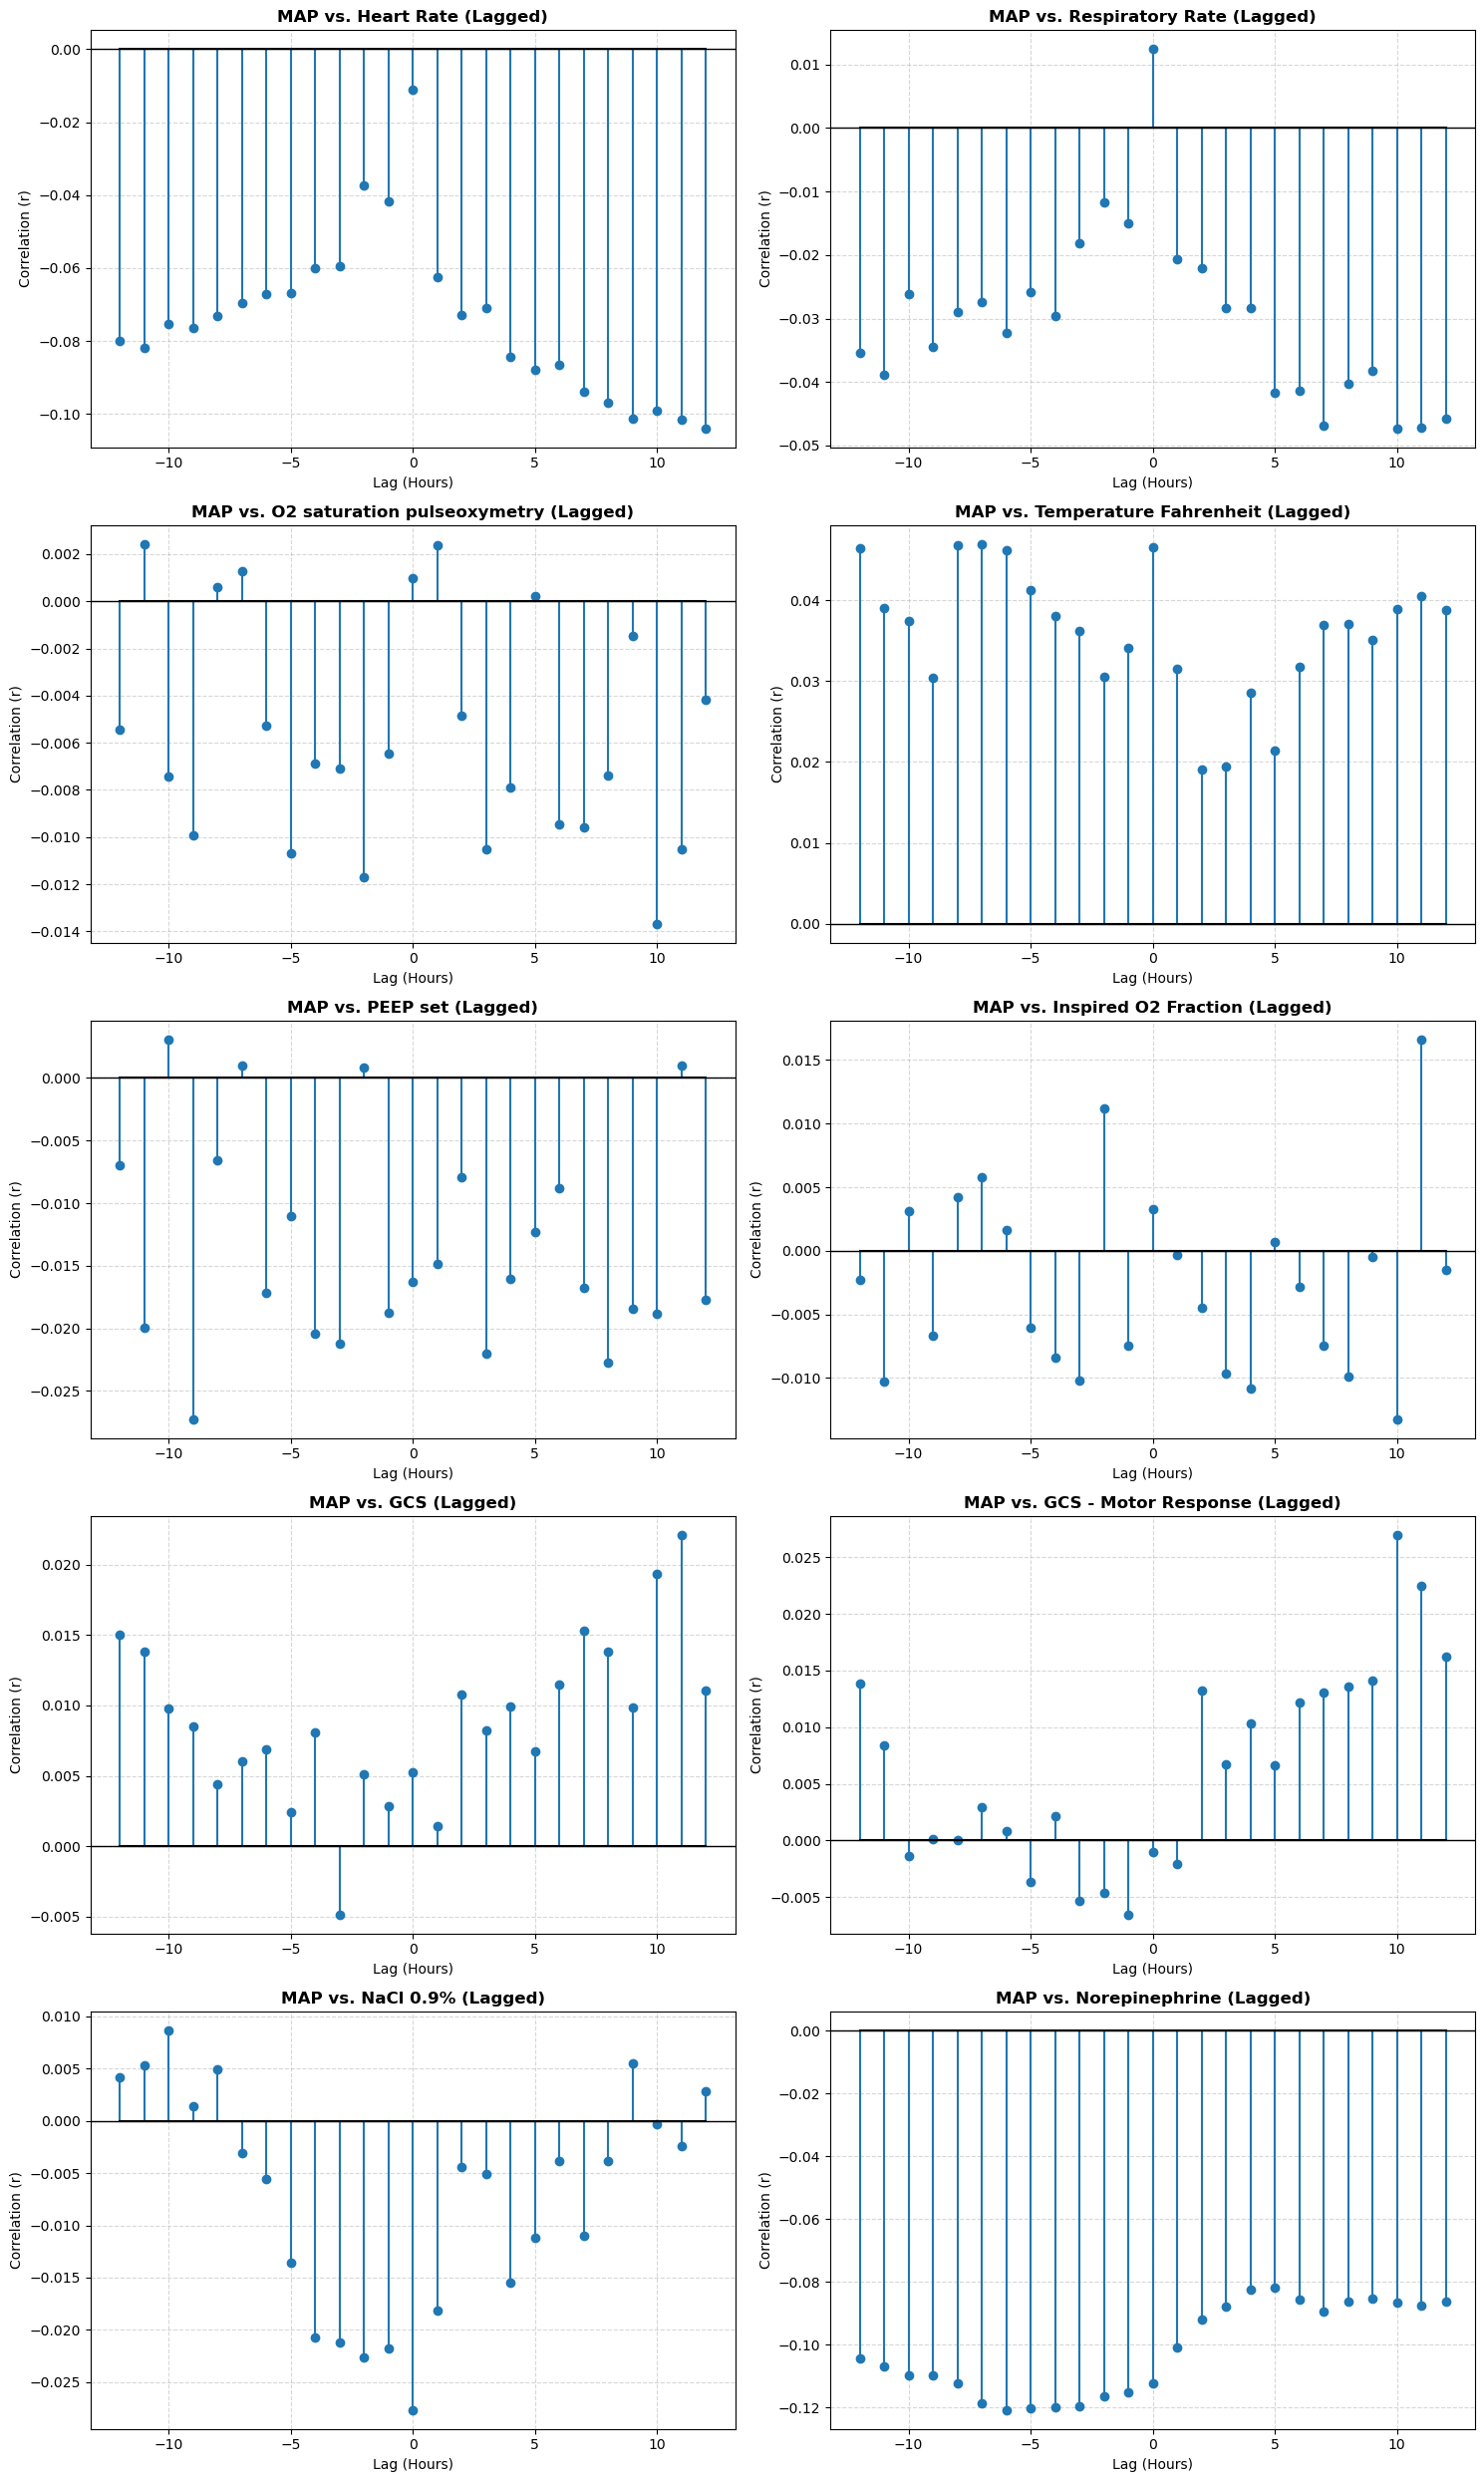

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Updated feature list (Total of 8 features)
features_to_plot = [
    'Heart Rate', 'Respiratory Rate', 'O2 saturation pulseoxymetry', 
    'Temperature Fahrenheit', 'PEEP set', 'Inspired O2 Fraction', 
    'GCS', 'GCS - Motor Response', 'NaCl 0.9%', 'Norepinephrine'
]

max_lag = 12
n_features = len(features_to_plot)
cols = 2
rows = (n_features + 1) // cols  # Dynamically calculate required rows

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Standardize data for cross-correlation [cite: 85, 95]
    y = (df_final_with_input['MAP'] - df_final_with_input['MAP'].mean()) / df_final_with_input['MAP'].std()
    x = (df_final_with_input[feature] - df_final_with_input[feature].mean()) / df_final_with_input[feature].std()
    
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = [y.corr(x.shift(lag)) for lag in lags]
    
    ax = axes[i]
    ax.stem(lags, corrs, basefmt="k-")
    ax.set_title(f'MAP vs. {feature} (Lagged)', fontweight='bold')
    ax.set_xlabel('Lag (Hours)')
    ax.set_ylabel('Correlation (r)')
    ax.axhline(0, color='black', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)

# Only delete subplots if there are more axes than features 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# 1. Define physiologically plausible bounds
MAP_LOWER = 30
MAP_UPPER = 250

# 2. Filter the dataframe
# Option A: Remove the rows entirely
df_cleaned = df_final[(df_final['MAP'] >= MAP_LOWER) & (df_final['MAP'] <= MAP_UPPER)].copy()

# Option B (Better for Time-Series): Mask them as NaN so the grid remains intact
# df_final.loc[(df_final['MAP'] < MAP_LOWER) | (df_final['MAP'] > MAP_UPPER), 'MAP'] = np.nan

/var/folders/5n/m32d0hsx4959r42x3mssyjj40000gn/T/ipykernel_30468/3634296663.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender_female', y='MAP', data=df_final_with_input, palette='Set2')


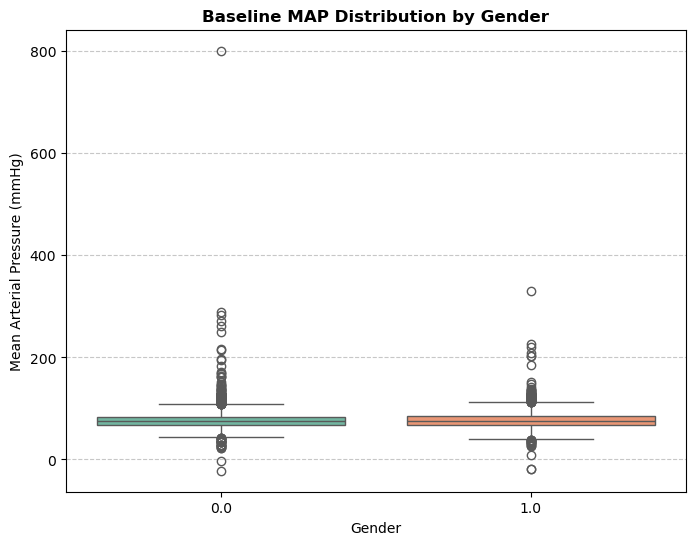

In [76]:
# Scatter plot for static exogenous factors like gender and age
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='gender_female', y='MAP', data=df_final_with_input, palette='Set2')
plt.title('Baseline MAP Distribution by Gender', fontweight='bold')
plt.ylabel('Mean Arterial Pressure (mmHg)')
plt.xlabel('Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

TypeError: Invalid object type at position 0

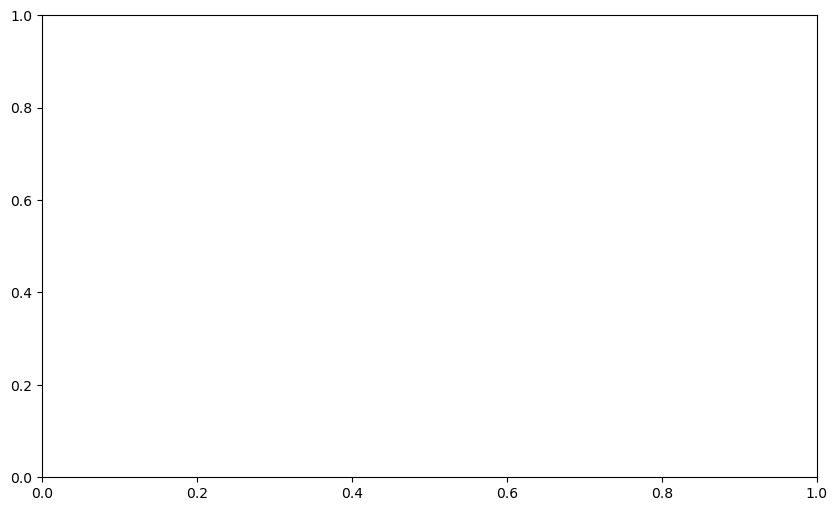

In [77]:
# Create age bins (e.g., 20-30, 30-40, etc.)
df_final_with_input['age_bin'] = pd.cut(df_final_with_input['age'], bins=np.arange(18, 100, 10))

plt.figure(figsize=(10, 6))
sns.lineplot(x='age_bin', y='MAP', data=df_final_with_input, marker='o', color='teal')
plt.title('Mean MAP Trend Across Age Decades', fontweight='bold')
plt.ylabel('Mean MAP (mmHg)')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()